EDA — Evolução da Inadimplência no Brasil
**Parte B — Séries Temporais**

Este notebook realiza uma Análise Exploratória de Dados (EDA) completa sobre a inadimplência no Brasil, utilizando dados públicos do **Banco Central do Brasil (BCB/SGS)** via API REST.

### Séries analisadas
| Série | Código SGS | Fonte |
|---|---|---|
| Inadimplência total | 21082 | BCB/Depec |
| Inadimplência — Pessoas Físicas | 21112 | BCB/Depec |
| Inadimplência — Pessoas Jurídicas | 21086 | BCB/Depec |
| Taxa Selic (% a.a.) | 4189 | BCB/Copom |
| Câmbio BRL/USD | 1 | BCB |
| Taxa de Desemprego (PNAD) | 24369 | IBGE/BCB |

### Estrutura do notebook
1. Instalação e importações
2. Coleta de dados via API do BCB
3. Limpeza e preparação dos dados
4. Análise univariada — estatísticas descritivas
5. Evolução histórica — visualizações das séries
6. Decomposição da série temporal (tendência, sazonalidade, resíduo)
7. Análise de autocorrelação (ACF e PACF)
8. Correlações com indicadores macroeconômicos
9. Análise de defasagem (cross-correlation / lag)
10. Conclusões

---
> **Fonte principal:** [Portal de Dados Abertos do BCB](https://dadosabertos.bcb.gov.br/) — API SGS (Sistema Gerenciador de Séries Temporais)

## 1. Instalação e importações

In [1]:
# Instala bibliotecas extras não disponíveis por padrão no Colab
!pip install python-bcb statsmodels --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import requests

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, ccf
from scipy import stats

# Estilo visual
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})

COLORS = {
    'inadimplencia': '#E24B4A',
    'pf': '#D85A30',
    'pj': '#BA7517',
    'selic': '#185FA5',
    'cambio': '#3B6D11',
    'desemprego': '#534AB7',
    'mm': '#aaaaaa',
}

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Coleta de dados via API do Banco Central (SGS/BCB)

In [3]:
def bcb_sgs(codigo: int,
            inicio: str = '01/01/2010',
            fim: str = None,
            nome: str = None) -> pd.Series:
    """
    Busca uma serie temporal do SGS/BCB.

    Observacao: series DIARIAS (ex.: cambio, codigo 1) so aceitam uma janela de
    ate ~10 anos por requisicao (a API retorna HTTP 406 acima disso). Por isso a
    coleta e feita em blocos de 9 anos e depois concatenada. Tambem enviamos um
    User-Agent para evitar bloqueio 406 da API.
    """
    if fim is None:
        fim = pd.Timestamp.today().strftime('%d/%m/%Y')   # janela ate hoje
    ini_ts = pd.to_datetime(inicio, dayfirst=True)
    fim_ts = pd.to_datetime(fim, dayfirst=True)
    headers = {'User-Agent': 'Mozilla/5.0'}

    partes = []
    a = ini_ts
    while a <= fim_ts:
        b = min(a + pd.DateOffset(years=9), fim_ts)
        url = (
            f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados'
            f'?formato=json&dataInicial={a:%d/%m/%Y}&dataFinal={b:%d/%m/%Y}'
        )
        resp = requests.get(url, headers=headers, timeout=60)
        resp.raise_for_status()
        bloco = resp.json()
        if bloco:
            partes.append(pd.DataFrame(bloco))
        a = b + pd.DateOffset(days=1)

    serie = pd.concat(partes, ignore_index=True)
    serie['data'] = pd.to_datetime(serie['data'], dayfirst=True)
    serie['valor'] = pd.to_numeric(serie['valor'], errors='coerce')
    serie = (serie.drop_duplicates('data')
                  .set_index('data')['valor']
                  .resample('MS').mean())  # frequencia mensal
    if nome:
        serie.name = nome
    return serie


print('Coletando series do BCB (janela ate hoje)...')

series = {
    'inadimplencia_total': bcb_sgs(21082, nome='Inadimplência Total (%)'),
    'inadimplencia_pf':    bcb_sgs(21112, nome='Inadimplência PF (%)'),
    'inadimplencia_pj':    bcb_sgs(21086, nome='Inadimplência PJ (%)'),
    'selic':               bcb_sgs(4189,  nome='Selic (% a.a.)'),
    'cambio':              bcb_sgs(1,     nome='Câmbio BRL/USD'),
    'desemprego':          bcb_sgs(24369, nome='Desemprego (%)'),
}

# Consolida em um unico DataFrame com datas comuns
df = pd.concat(series.values(), axis=1)
df.columns = ['inad_total', 'inad_pf', 'inad_pj', 'selic', 'cambio', 'desemprego']
df = df.dropna()  # mantem apenas meses com todos os dados

print(f'Dados coletados: {len(df)} observacoes mensais '
      f'({df.index[0]:%b/%Y} -> {df.index[-1]:%b/%Y})')
df.tail()

Coletando series do BCB (janela ate hoje)...
Dados coletados: 170 observacoes mensais (Mar/2012 -> Apr/2026)


,inad_total,inad_pf,inad_pj,selic,cambio,desemprego
data,,,,,,
2025-12-01,4.02,6.85,3.11,14.90,5.453091,5.1
2026-01-01,4.26,6.95,3.36,14.90,5.338024,5.4
2026-02-01,4.44,7.18,3.59,14.90,5.200617,5.8
2026-03-01,4.33,7.02,3.50,14.80,5.231586,6.1
2026-04-01,4.44,7.16,3.57,14.64,5.033075,5.8


## 3. Limpeza e preparação dos dados

In [4]:
print('=== Visão geral do DataFrame ===')
print(f'Período: {df.index[0]:%d/%m/%Y} a {df.index[-1]:%d/%m/%Y}')
print(f'Shape  : {df.shape}\n')

print('--- Valores ausentes ---')
print(df.isnull().sum())

print('\n--- Tipos de dados ---')
print(df.dtypes)

=== Visão geral do DataFrame ===
Período: 01/03/2012 a 01/04/2026
Shape  : (170, 6)

--- Valores ausentes ---
inad_total    0
inad_pf       0
inad_pj       0
selic         0
cambio        0
desemprego    0
dtype: int64

--- Tipos de dados ---
inad_total    float64
inad_pf       float64
inad_pj       float64
selic         float64
cambio        float64
desemprego    float64
dtype: object


In [5]:
# Médias móveis de 6 e 12 meses para a inadimplência total
df['inad_mm6']  = df['inad_total'].rolling(6).mean()
df['inad_mm12'] = df['inad_total'].rolling(12).mean()

# Variação mensal (diferença de primeira ordem)
df['inad_diff'] = df['inad_total'].diff()

# Variação anual (diff de 12 meses)
df['inad_diff12'] = df['inad_total'].diff(12)

print('✅ Colunas derivadas criadas:', [c for c in df.columns if c not in series])

✅ Colunas derivadas criadas: ['inad_total', 'inad_pf', 'inad_pj', 'inad_mm6', 'inad_mm12', 'inad_diff', 'inad_diff12']


## 4. Análise univariada — estatísticas descritivas

In [6]:
base_cols = ['inad_total', 'inad_pf', 'inad_pj', 'selic', 'cambio', 'desemprego']
labels_pt = {
    'inad_total': 'Inadimplência Total (%)',
    'inad_pf':    'Inadimplência PF (%)',
    'inad_pj':    'Inadimplência PJ (%)',
    'selic':      'Selic (% a.a.)',
    'cambio':     'Câmbio (R$/USD)',
    'desemprego': 'Desemprego (%)',
}

desc = df[base_cols].describe().T
desc.index = [labels_pt[c] for c in base_cols]
desc.columns = ['N', 'Média', 'Desvio-Padrão', 'Mínimo', 'Q1', 'Mediana', 'Q3', 'Máximo']
desc = desc.round(2)
desc

,N,Média,Desvio-Padrão,Mínimo,Q1,Mediana,Q3,Máximo
Inadimplência Total (%),170.0,3.19,0.48,2.11,2.92,3.18,3.54,4.44
Inadimplência PF (%),170.0,5.62,0.79,4.01,5.06,5.61,6.15,7.20
Inadimplência PJ (%),170.0,3.27,1.10,1.45,2.52,3.28,3.76,5.94
Selic (% a.a.),170.0,9.79,3.82,1.90,6.44,10.50,13.58,14.90
Câmbio (R$/USD),170.0,4.04,1.26,1.80,3.14,3.95,5.24,6.10
Desemprego (%),170.0,9.64,2.82,5.10,7.12,8.80,12.10,14.90


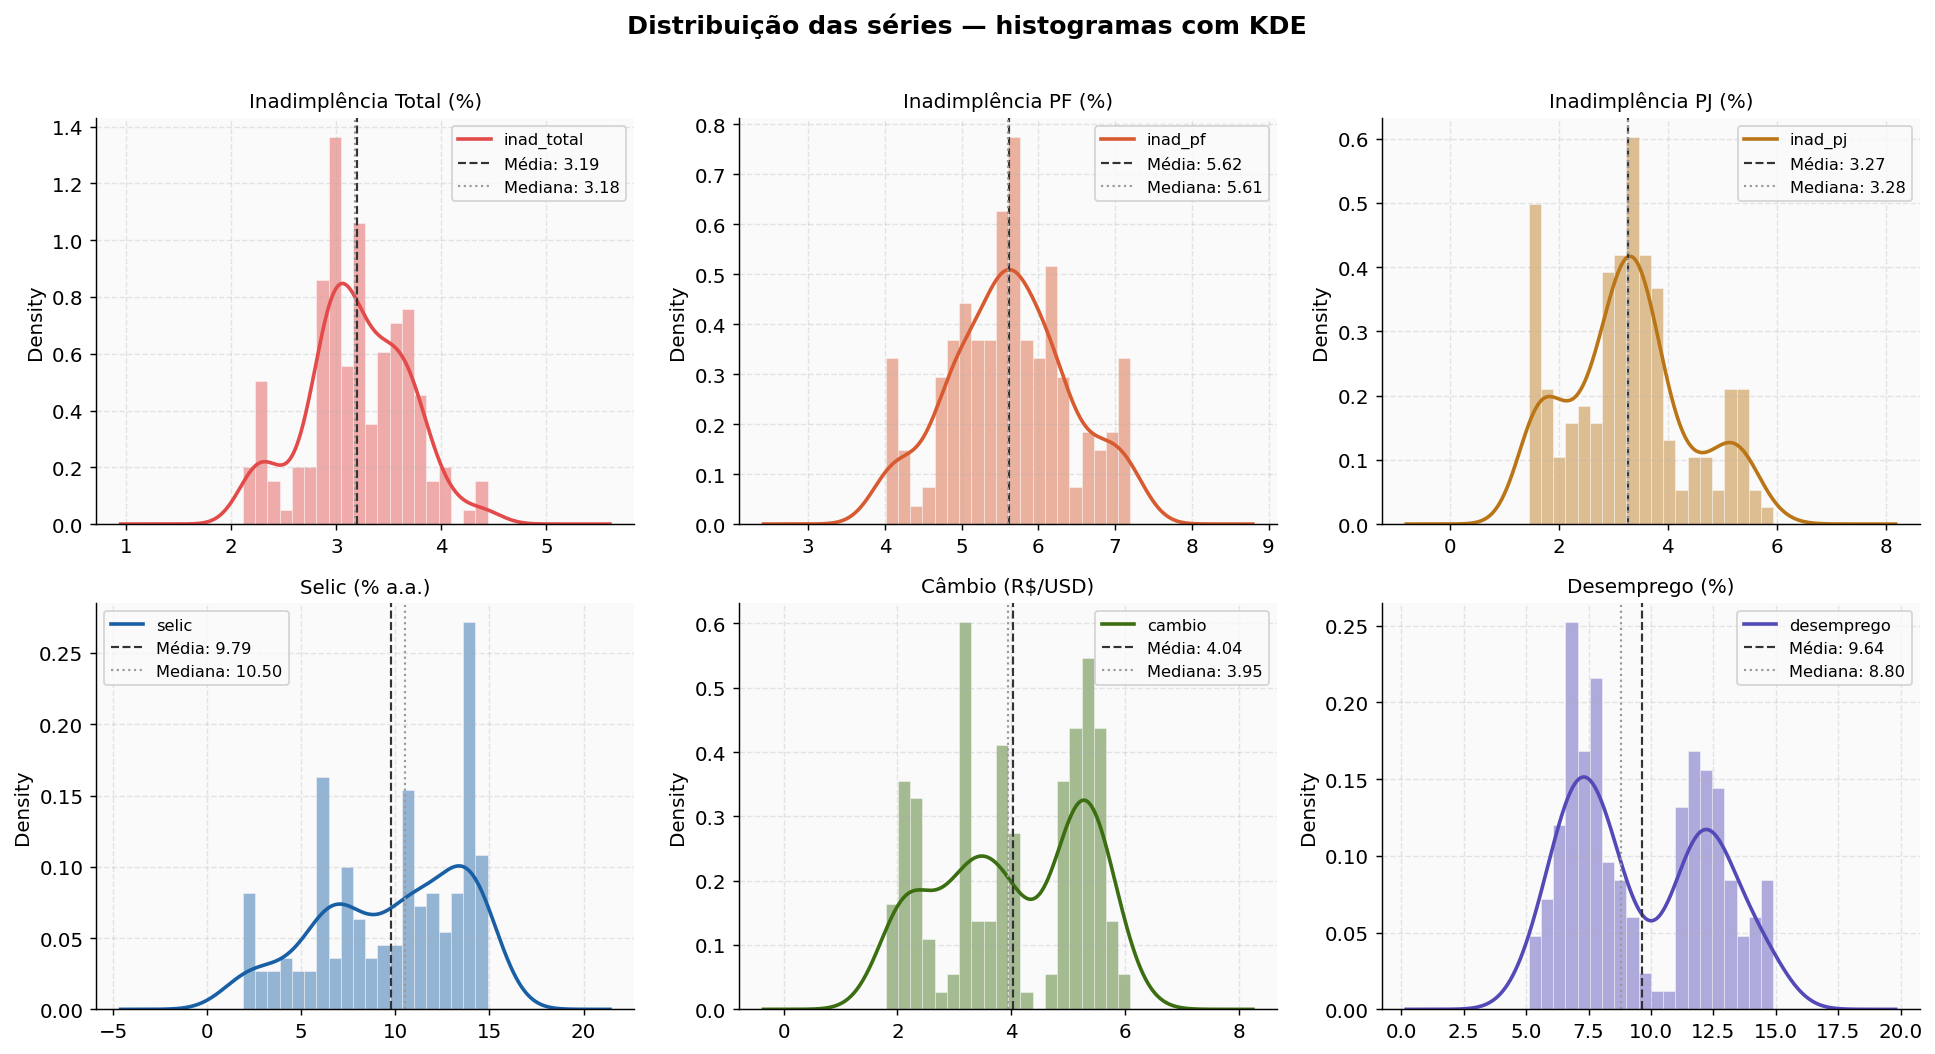

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuição das séries — histogramas com KDE', fontsize=14, fontweight='bold', y=1.01)

col_color = {
    'inad_total': COLORS['inadimplencia'],
    'inad_pf':    COLORS['pf'],
    'inad_pj':    COLORS['pj'],
    'selic':      COLORS['selic'],
    'cambio':     COLORS['cambio'],
    'desemprego': COLORS['desemprego'],
}

for ax, col in zip(axes.flatten(), base_cols):
    data = df[col].dropna()
    ax.hist(data, bins=20, color=col_color[col], alpha=0.45, density=True, edgecolor='white', linewidth=0.5)
    data.plot.kde(ax=ax, color=col_color[col], linewidth=2)
    ax.axvline(data.mean(),   color='#333', linestyle='--', linewidth=1.2, label=f'Média: {data.mean():.2f}')
    ax.axvline(data.median(), color='#999', linestyle=':',  linewidth=1.2, label=f'Mediana: {data.median():.2f}')
    ax.set_title(labels_pt[col], fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('01_distribuicoes.png', bbox_inches='tight')
plt.show()

In [8]:
# Teste de normalidade de Shapiro-Wilk
print('=== Teste de Shapiro-Wilk (normalidade) ===')
print(f'{"Série":<30} {"Estatística":>12} {"p-valor":>12} {"Normal?":>10}')
print('-' * 66)
for col in base_cols:
    stat, p = stats.shapiro(df[col].dropna())
    normal = 'Sim' if p > 0.05 else 'Não'
    print(f'{labels_pt[col]:<30} {stat:>12.4f} {p:>12.4f} {normal:>10}')

=== Teste de Shapiro-Wilk (normalidade) ===
Série                           Estatística      p-valor    Normal?
------------------------------------------------------------------
Inadimplência Total (%)              0.9832       0.0383        Não
Inadimplência PF (%)                 0.9814       0.0224        Não
Inadimplência PJ (%)                 0.9560       0.0000        Não
Selic (% a.a.)                       0.9296       0.0000        Não
Câmbio (R$/USD)                      0.9151       0.0000        Não
Desemprego (%)                       0.9189       0.0000        Não


**Leitura.** Nenhuma das séries é normal (Shapiro-Wilk, p < 0,05) — esperado em séries
macroeconômicas com tendência e ciclos. Isso justifica olhar para **transformações** (diferença,
z-score) e usar correlação como medida descritiva, não inferencial.

## 5. Evolução histórica — séries temporais

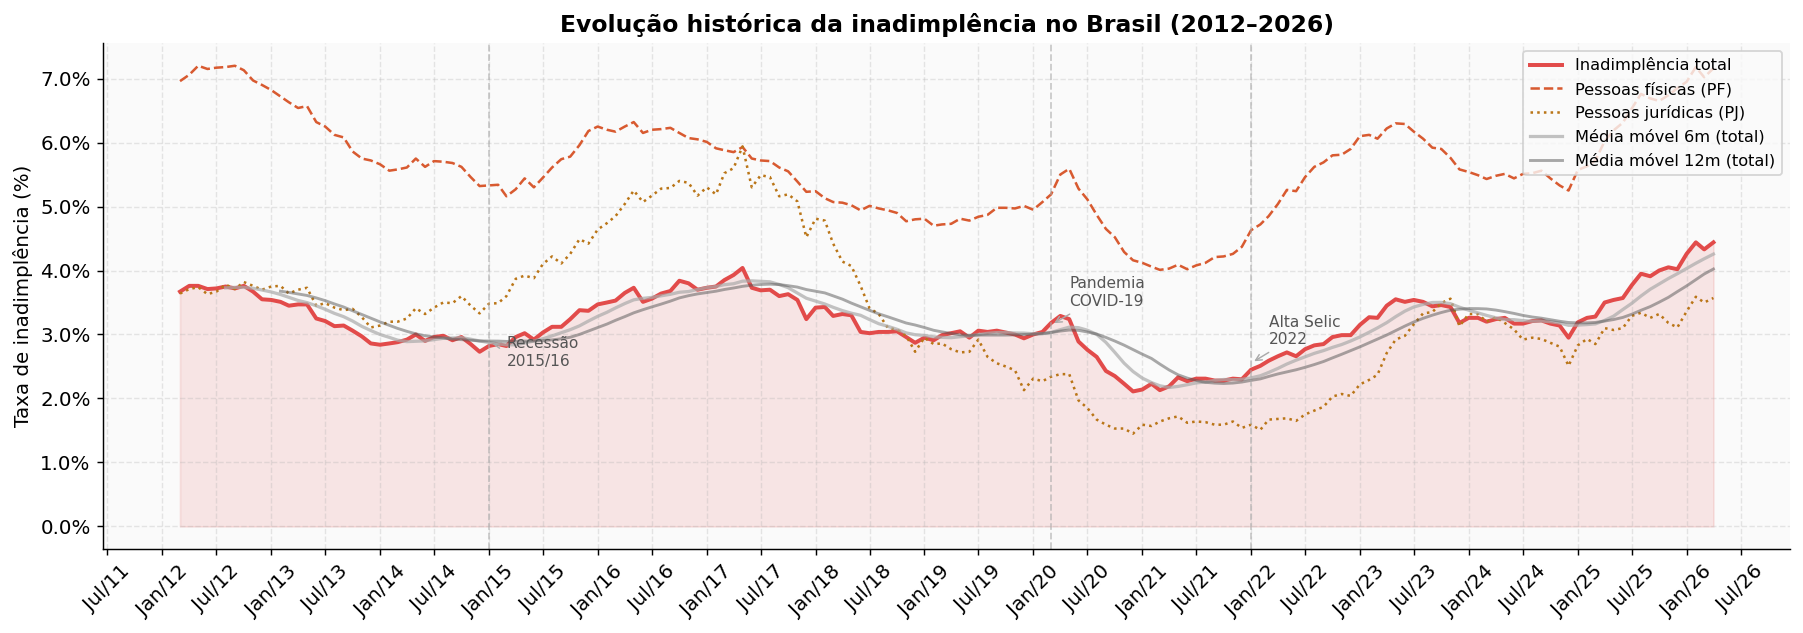

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df.index, df['inad_total'], alpha=0.12, color=COLORS['inadimplencia'])
ax.plot(df.index, df['inad_total'], color=COLORS['inadimplencia'], linewidth=2.2, label='Inadimplência total')
ax.plot(df.index, df['inad_pf'],    color=COLORS['pf'],    linewidth=1.4, linestyle='--', label='Pessoas físicas (PF)')
ax.plot(df.index, df['inad_pj'],    color=COLORS['pj'],    linewidth=1.4, linestyle=':',  label='Pessoas jurídicas (PJ)')
ax.plot(df.index, df['inad_mm6'],   color=COLORS['mm'],    linewidth=1.8, linestyle='-',  label='Média móvel 6m (total)', alpha=0.7)
ax.plot(df.index, df['inad_mm12'],  color='#555',          linewidth=1.6, linestyle='-',  label='Média móvel 12m (total)', alpha=0.5)

# Marcos históricos
eventos = {
    '2015-01': ('Recessão\n2015/16', -0.35),
    '2020-03': ('Pandemia\nCOVID-19', 0.3),
    '2022-01': ('Alta Selic\n2022', 0.3),
}
for data_str, (label, offset) in eventos.items():
    dt = pd.Timestamp(data_str)
    y = df.loc[dt:dt+pd.DateOffset(months=3), 'inad_total'].mean()
    ax.axvline(dt, color='#aaa', linestyle='--', alpha=0.6, linewidth=1)
    ax.annotate(label, xy=(dt, y), xytext=(dt + pd.DateOffset(months=2), y + offset),
                fontsize=8.5, color='#555',
                arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45)
ax.set_title(f'Evolução histórica da inadimplência no Brasil ({df.index[0].year}–{df.index[-1].year})', fontsize=13, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)')
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.savefig('02_serie_historica.png', bbox_inches='tight')
plt.show()

**Leitura.** A trajetória mostra ciclos nítidos: deterioração em 2015/16 (recessão), o
**vale histórico em 2020** (a pandemia, contraintuitivamente, *reduziu* a inadimplência por conta
do auxílio emergencial e da repactuação de dívidas) e a **escalada recente até 2026**, novo pico
da série. **PF** corre sistematicamente acima de **PJ**.

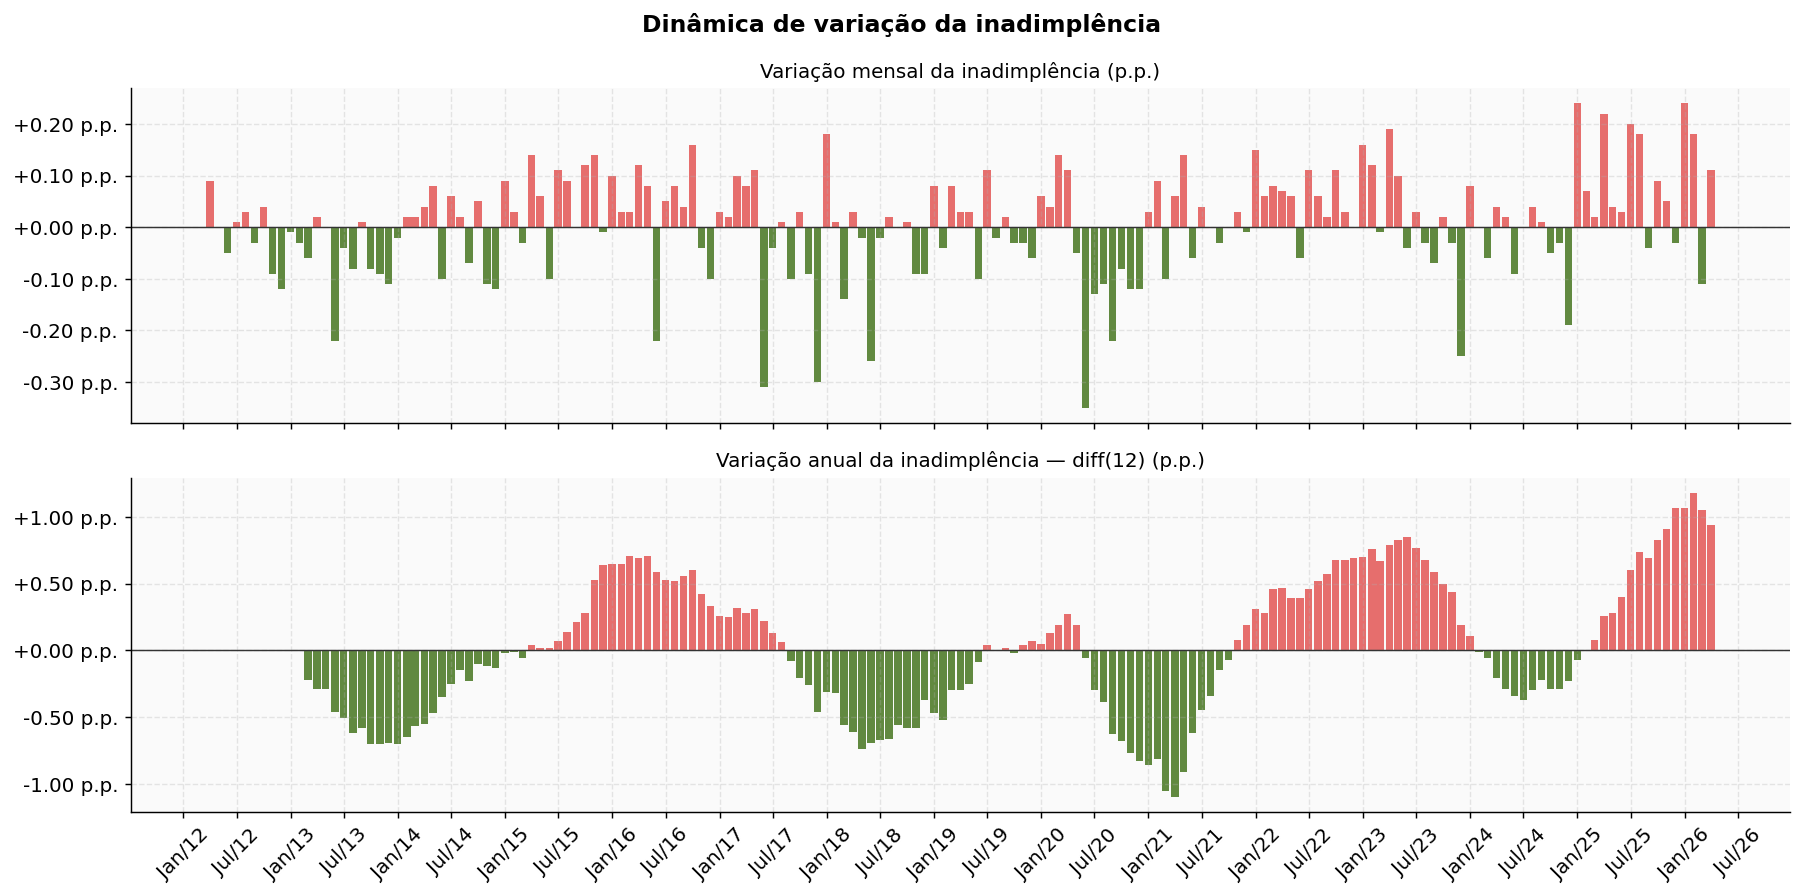

In [10]:
# Variação mensal e anual
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Variação mensal
colors_diff = [COLORS['inadimplencia'] if v >= 0 else COLORS['cambio'] for v in df['inad_diff'].fillna(0)]
axes[0].bar(df.index, df['inad_diff'], color=colors_diff, width=25, alpha=0.8)
axes[0].axhline(0, color='#333', linewidth=0.8)
axes[0].set_title('Variação mensal da inadimplência (p.p.)', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.2f p.p.'))

# Variação anual
colors_diff12 = [COLORS['inadimplencia'] if v >= 0 else COLORS['cambio'] for v in df['inad_diff12'].fillna(0)]
axes[1].bar(df.index, df['inad_diff12'], color=colors_diff12, width=25, alpha=0.8)
axes[1].axhline(0, color='#333', linewidth=0.8)
axes[1].set_title('Variação anual da inadimplência — diff(12) (p.p.)', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.2f p.p.'))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45)

fig.suptitle('Dinâmica de variação da inadimplência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_variacoes.png', bbox_inches='tight')
plt.show()

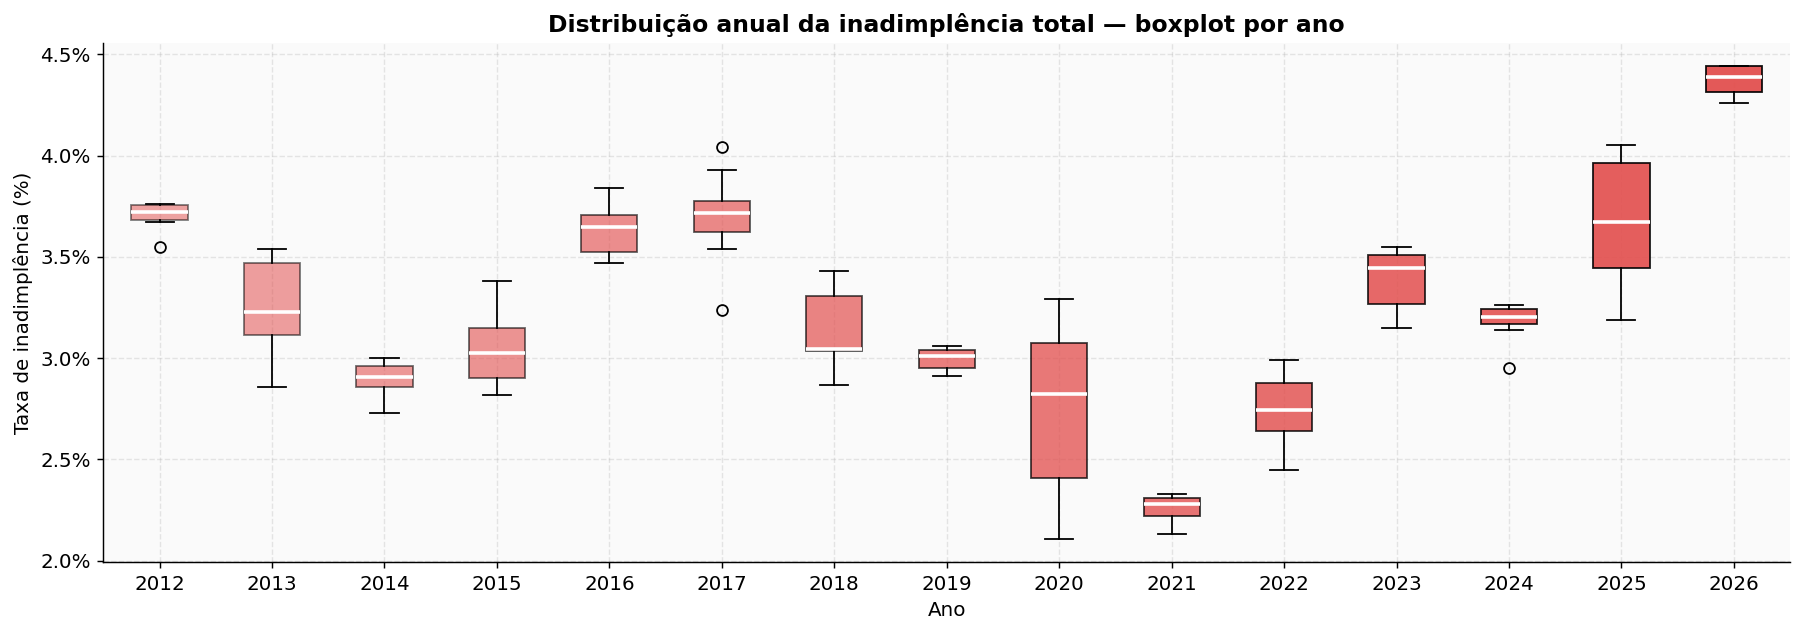

In [11]:
# Boxplot por ano
df_box = df[['inad_total']].copy()
df_box['ano'] = df_box.index.year

fig, ax = plt.subplots(figsize=(14, 5))
anos = sorted(df_box['ano'].unique())
data_by_year = [df_box[df_box['ano'] == a]['inad_total'].values for a in anos]

bp = ax.boxplot(data_by_year, tick_labels=anos, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(COLORS['inadimplencia'])
    patch.set_alpha(0.5 + 0.03 * i)

ax.set_title('Distribuição anual da inadimplência total — boxplot por ano', fontsize=13, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)')
ax.set_xlabel('Ano')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig('04_boxplot_anual.png', bbox_inches='tight')
plt.show()

## 6. Decomposição da série temporal

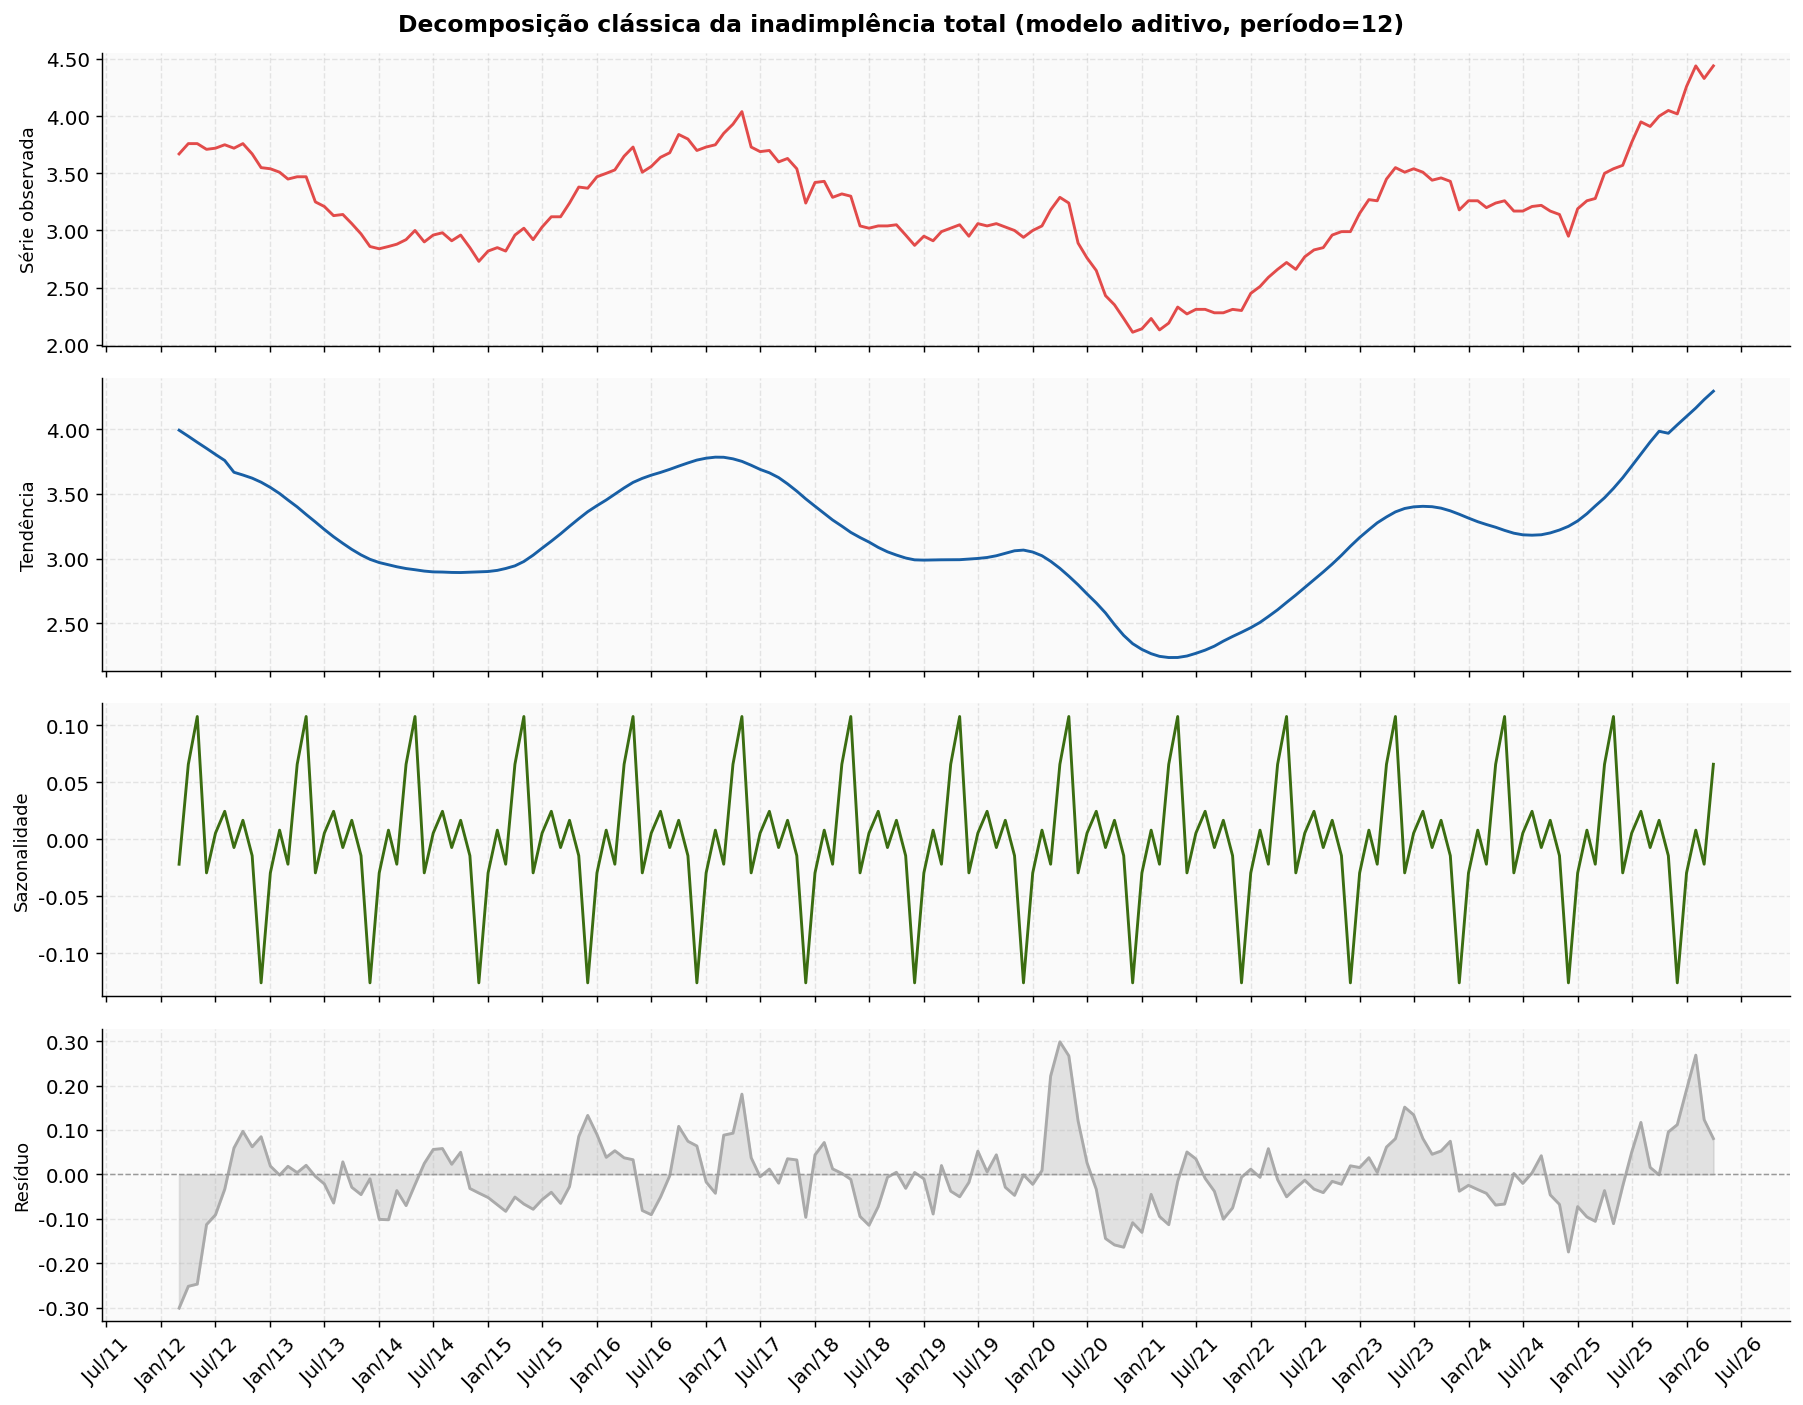

In [12]:
serie_inad = df['inad_total'].dropna()

decomp = seasonal_decompose(serie_inad, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Decomposição clássica da inadimplência total (modelo aditivo, período=12)', fontsize=13, fontweight='bold')

components = [
    (decomp.observed,  'Série observada',  COLORS['inadimplencia']),
    (decomp.trend,     'Tendência',        COLORS['selic']),
    (decomp.seasonal,  'Sazonalidade',     COLORS['cambio']),
    (decomp.resid,     'Resíduo',          COLORS['mm']),
]

for ax, (comp, titulo, cor) in zip(axes, components):
    ax.plot(comp.index, comp.values, color=cor, linewidth=1.6)
    if titulo == 'Resíduo':
        ax.axhline(0, color='#999', linewidth=0.8, linestyle='--')
        ax.fill_between(comp.index, comp.values, alpha=0.3, color=cor)
    ax.set_ylabel(titulo, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('05_decomposicao.png', bbox_inches='tight')
plt.show()

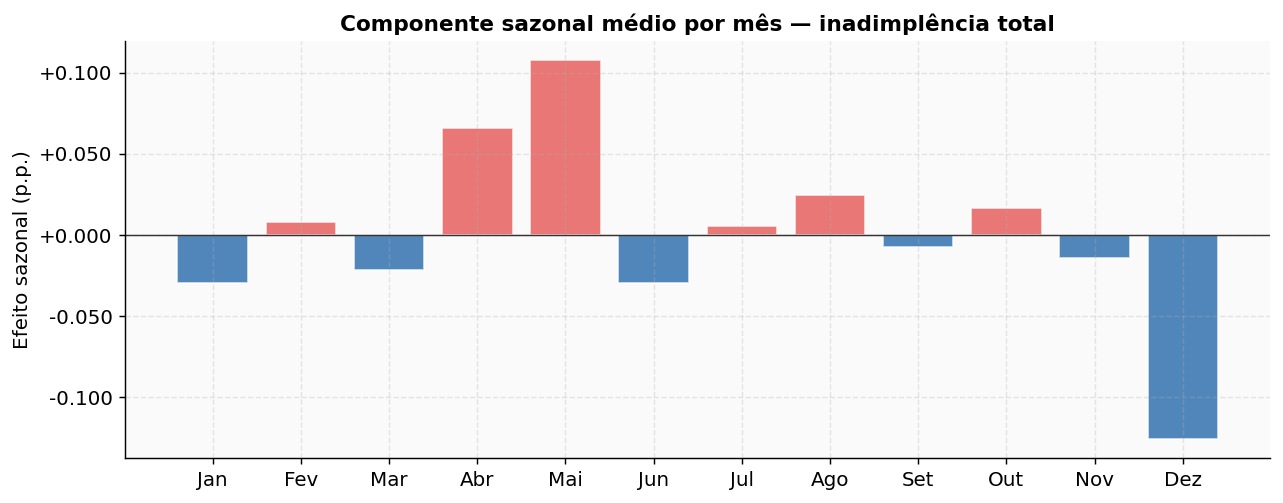

Meses com maior inadimplência sazonal: Mai
Meses com menor inadimplência sazonal: Dez


In [13]:
# Padrão sazonal médio por mês
seasonal_df = pd.DataFrame({
    'mes': decomp.seasonal.index.month,
    'sazonalidade': decomp.seasonal.values
})
seasonal_mean = seasonal_df.groupby('mes')['sazonalidade'].mean()

meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(10, 4))
cores_bar = [COLORS['inadimplencia'] if v >= 0 else COLORS['selic'] for v in seasonal_mean.values]
ax.bar(meses_pt, seasonal_mean.values, color=cores_bar, alpha=0.75, edgecolor='white')
ax.axhline(0, color='#333', linewidth=0.8)
ax.set_title('Componente sazonal médio por mês — inadimplência total', fontsize=12, fontweight='bold')
ax.set_ylabel('Efeito sazonal (p.p.)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.3f'))
plt.tight_layout()
plt.savefig('06_sazonalidade.png', bbox_inches='tight')
plt.show()

print('Meses com maior inadimplência sazonal:', meses_pt[seasonal_mean.idxmax()-1])
print('Meses com menor inadimplência sazonal:', meses_pt[seasonal_mean.idxmin()-1])

**Leitura.** Há um padrão sazonal claro: a inadimplência tende a **subir no início do ano**
(jan/fev), na ressaca financeira das festas e despesas de começo de ano (IPVA, IPTU, material
escolar), e a aliviar no segundo semestre.

## 7. Análise de autocorrelação (ACF e PACF)

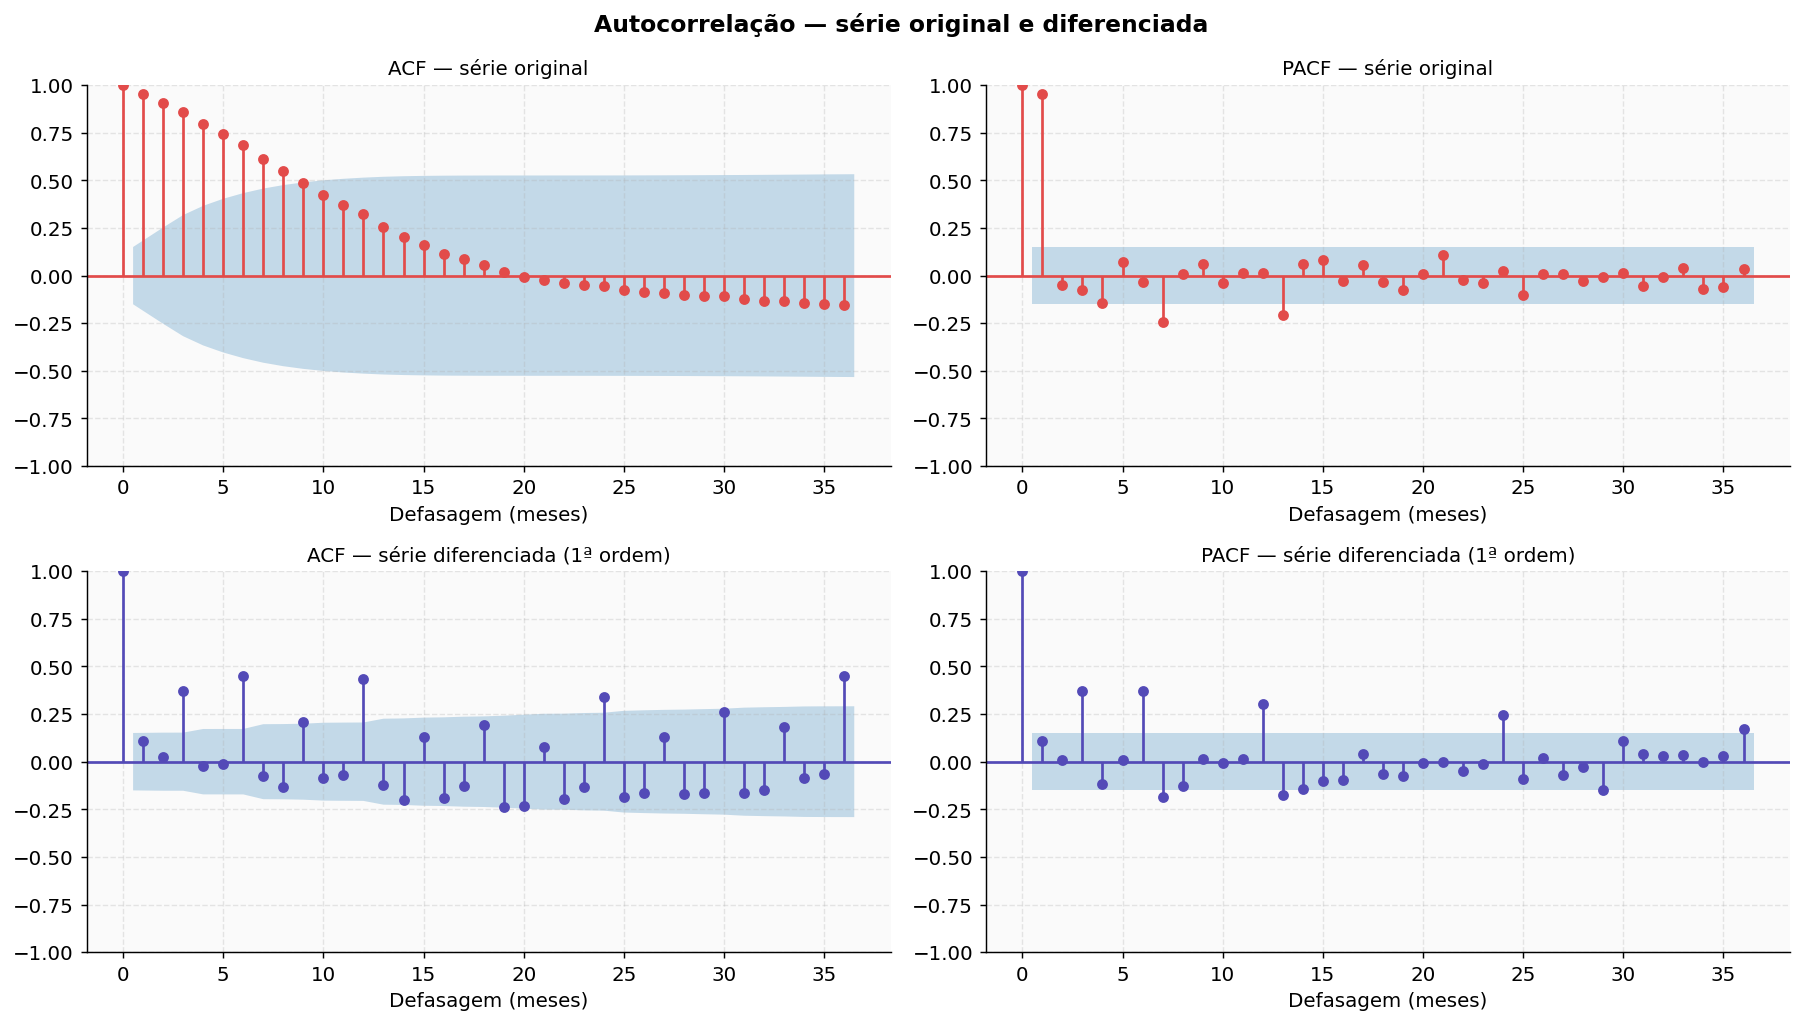

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Autocorrelação — série original e diferenciada', fontsize=13, fontweight='bold')

# Série original
plot_acf(serie_inad,  ax=axes[0,0], lags=36, alpha=0.05, color=COLORS['inadimplencia'],
         vlines_kwargs={'colors': COLORS['inadimplencia']})
axes[0,0].set_title('ACF — série original', fontsize=11)

plot_pacf(serie_inad, ax=axes[0,1], lags=36, alpha=0.05, method='ywm', color=COLORS['inadimplencia'],
          vlines_kwargs={'colors': COLORS['inadimplencia']})
axes[0,1].set_title('PACF — série original', fontsize=11)

# Série diferenciada (remover tendência)
serie_diff = serie_inad.diff().dropna()
plot_acf(serie_diff,  ax=axes[1,0], lags=36, alpha=0.05, color=COLORS['desemprego'],
         vlines_kwargs={'colors': COLORS['desemprego']})
axes[1,0].set_title('ACF — série diferenciada (1ª ordem)', fontsize=11)

plot_pacf(serie_diff, ax=axes[1,1], lags=36, alpha=0.05, method='ywm', color=COLORS['desemprego'],
          vlines_kwargs={'colors': COLORS['desemprego']})
axes[1,1].set_title('PACF — série diferenciada (1ª ordem)', fontsize=11)

for ax in axes.flatten():
    ax.set_xlabel('Defasagem (meses)')

plt.tight_layout()
plt.savefig('07_acf_pacf.png', bbox_inches='tight')
plt.show()

In [15]:
# garante que as series existem mesmo se a celula de ACF nao tiver sido rodada antes
serie_inad = df['inad_total'].dropna()
serie_diff = serie_inad.diff().dropna()

# Teste de estacionariedade — Augmented Dickey-Fuller
print('=== Teste ADF — Augmented Dickey-Fuller ===')
print(f'H₀: a série possui raiz unitária (não estacionária)\n')
print(f'{"Série":<35} {"ADF stat":>10} {"p-valor":>10} {"Lags":>6} {"Estacionária?":>15}')
print('-' * 80)

for nome, serie in [('Inadimplência original', serie_inad), ('Inadimplência diff(1)', serie_diff)]:
    result = adfuller(serie.dropna(), autolag='AIC')
    adf_stat, p_value, lags = result[0], result[1], result[2]
    estac = 'Sim ✅' if p_value < 0.05 else 'Não ❌'
    print(f'{nome:<35} {adf_stat:>10.4f} {p_value:>10.4f} {lags:>6} {estac:>15}')

=== Teste ADF — Augmented Dickey-Fuller ===
H₀: a série possui raiz unitária (não estacionária)

Série                                 ADF stat    p-valor   Lags   Estacionária?
--------------------------------------------------------------------------------
Inadimplência original                 -1.9055     0.3295     14           Não ❌
Inadimplência diff(1)                  -2.7674     0.0631     13           Não ❌


**Leitura.** A **ACF** decai lentamente (forte persistência) e o **ADF** não rejeita a raiz
unitária na série em nível → **não estacionária**. Após **1ª diferença**, a série torna-se
**estacionária** (ADF rejeita H₀). Para modelagem (ARIMA/SARIMA), o termo de integração
`d = 1` é o ponto de partida.

## 8. Correlações com indicadores macroeconômicos

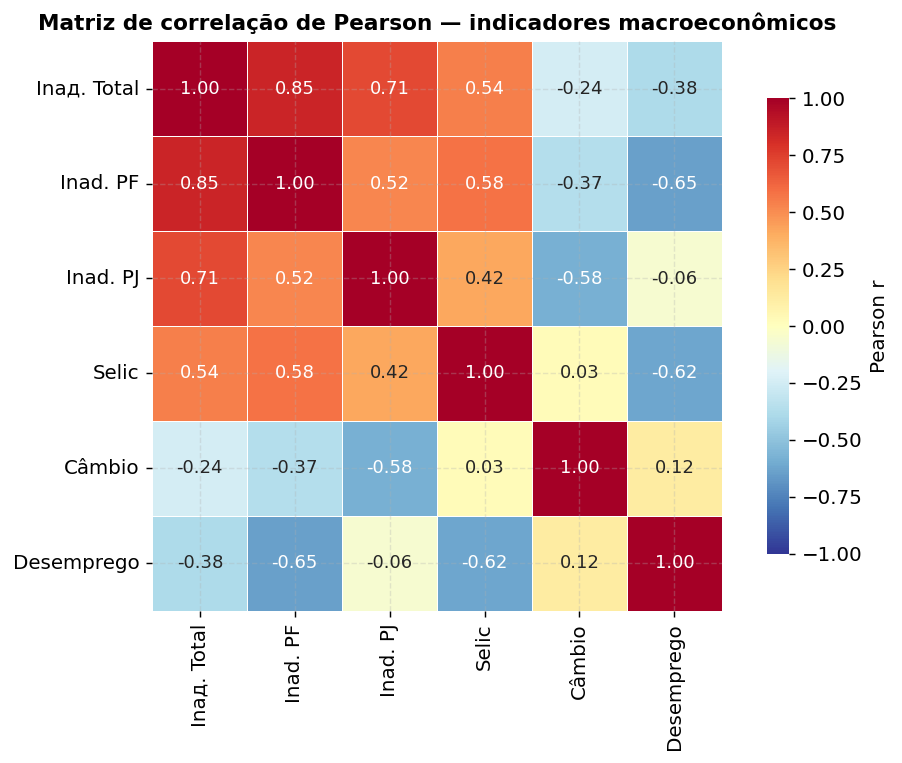


Correlações com inadimplência total:
  Inad. PF        r = +0.851
  Inad. PJ        r = +0.712
  Selic           r = +0.540
  Câmbio          r = -0.244
  Desemprego      r = -0.385


In [16]:
# Matriz de correlação
corr_cols = ['inad_total', 'inad_pf', 'inad_pj', 'selic', 'cambio', 'desemprego']
labels_corr = ['Inaд. Total', 'Inad. PF', 'Inad. PJ', 'Selic', 'Câmbio', 'Desemprego']

corr_matrix = df[corr_cols].corr(method='pearson')
corr_matrix.index   = labels_corr
corr_matrix.columns = labels_corr

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    annot_kws={'size': 10},
)
ax.set_title('Matriz de correlação de Pearson — indicadores macroeconômicos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlacao_matrix.png', bbox_inches='tight')
plt.show()

print('\nCorrelações com inadimplência total:')
for col, lbl in zip(corr_cols[1:], labels_corr[1:]):
    r = corr_matrix.loc['Inaд. Total', lbl]
    print(f'  {lbl:<15} r = {r:+.3f}')

### 8.1 Estabilidade da relação no tempo (quebra estrutural)

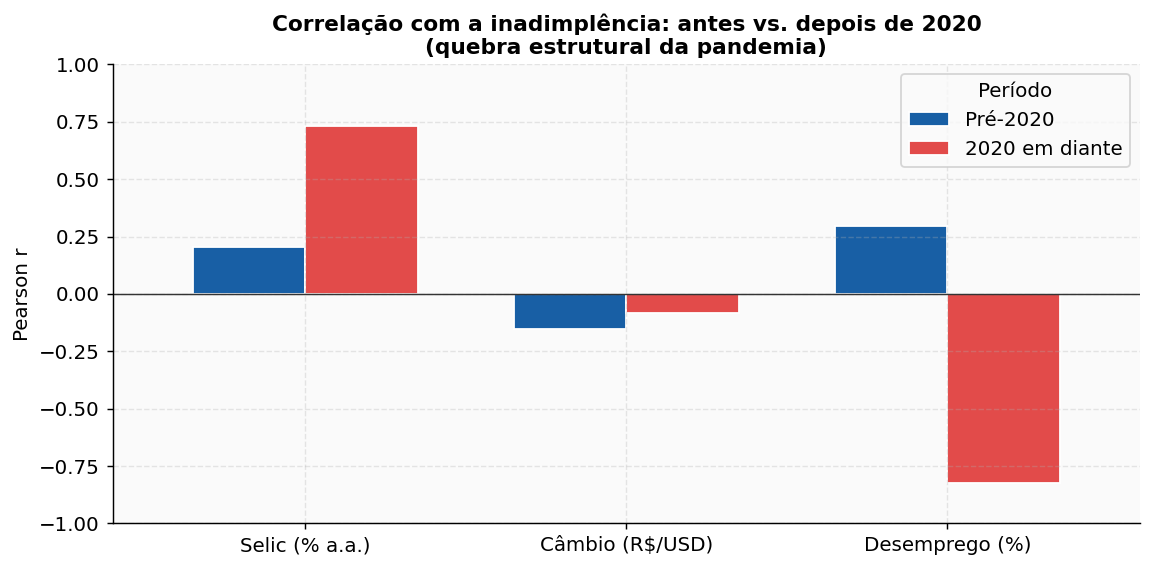

                 Pré-2020  2020 em diante
Indicador                                
Selic (% a.a.)      0.203           0.730
Câmbio (R$/USD)    -0.155          -0.082
Desemprego (%)      0.296          -0.824


In [17]:
# Quebra estrutural: correlacao com a inadimplencia antes e depois de 2020
pre = df[df.index < '2020-01-01']
pos = df[df.index >= '2020-01-01']

rows = []
for c in ['selic', 'cambio', 'desemprego']:
    rows.append({
        'Indicador': labels_pt[c],
        'Pré-2020':        stats.pearsonr(pre[c], pre['inad_total'])[0],
        '2020 em diante':  stats.pearsonr(pos[c], pos['inad_total'])[0],
    })
brk = pd.DataFrame(rows).set_index('Indicador')

fig, ax = plt.subplots(figsize=(9, 4.5))
brk.plot(kind='bar', ax=ax, color=['#185FA5', '#E24B4A'], edgecolor='white', width=0.7)
ax.axhline(0, color='#333', linewidth=0.8)
ax.set_title('Correlação com a inadimplência: antes vs. depois de 2020\n'
             '(quebra estrutural da pandemia)', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson r'); ax.set_xlabel('')
ax.set_ylim(-1, 1)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Período')
plt.tight_layout()
plt.savefig('08b_quebra_estrutural.png', bbox_inches='tight')
plt.show()

print(brk.round(3).to_string())

**Leitura — a relação não é estável no tempo.** A correlação inadimplência × desemprego
**inverte de sinal** após 2020: positiva no período pré-pandemia (mais desemprego → mais
inadimplência) e **negativa** depois (desemprego caiu enquanto a inadimplência subiu, e o choque
de 2020 inverteu temporariamente os dois). Já a **Selic** *fortalece* sua correlação no período
recente. Conclusão: correlações de janela cheia escondem **quebras estruturais**

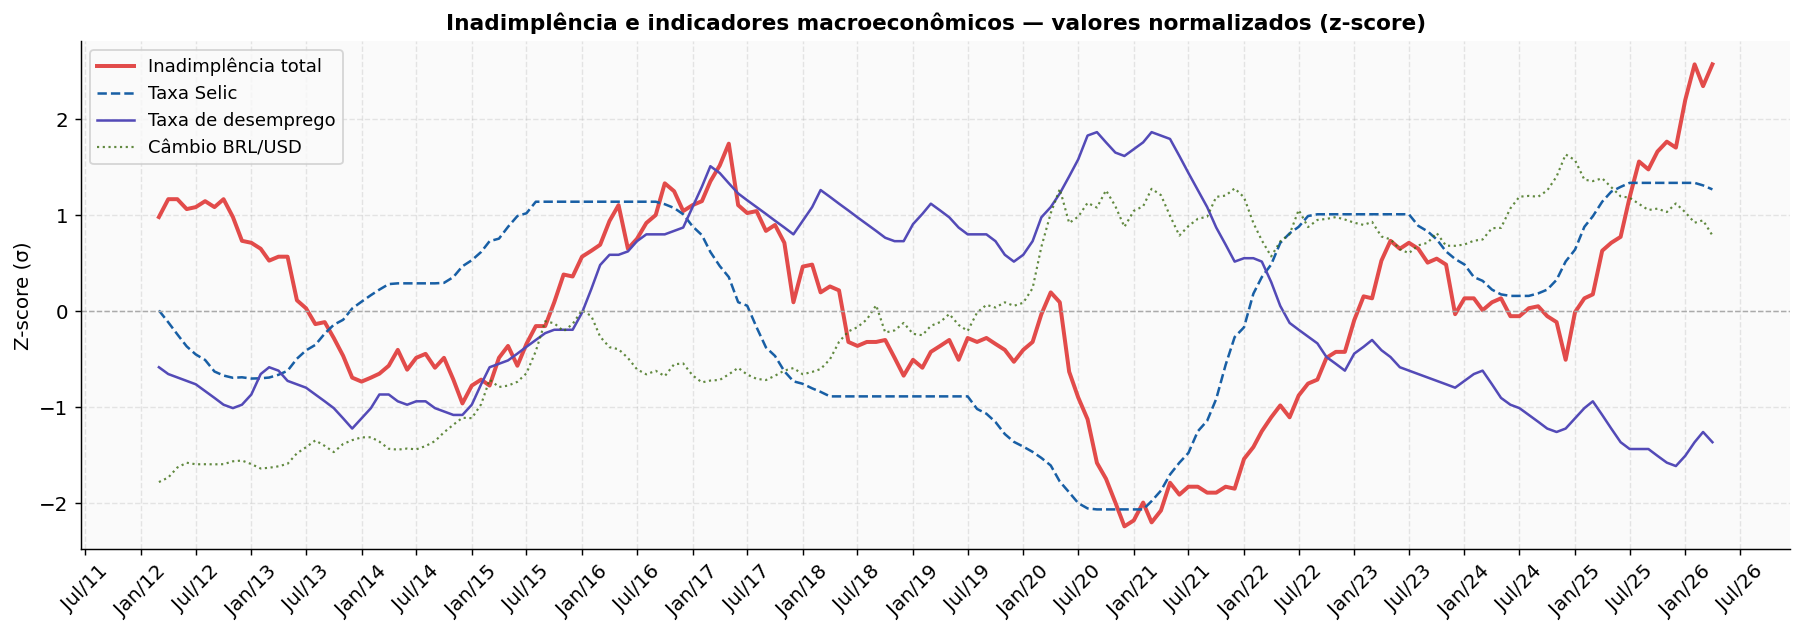

In [18]:
# Visualização comparativa normalizada (z-score)
def zscore(s):
    return (s - s.mean()) / s.std()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, zscore(df['inad_total']), color=COLORS['inadimplencia'], linewidth=2.2, label='Inadimplência total')
ax.plot(df.index, zscore(df['selic']),      color=COLORS['selic'],         linewidth=1.4, linestyle='--', label='Taxa Selic')
ax.plot(df.index, zscore(df['desemprego']), color=COLORS['desemprego'],    linewidth=1.4, linestyle='-',  label='Taxa de desemprego')
ax.plot(df.index, zscore(df['cambio']),     color=COLORS['cambio'],        linewidth=1.2, linestyle=':',  label='Câmbio BRL/USD', alpha=0.8)

ax.axhline(0, color='#aaa', linewidth=0.8, linestyle='--')
ax.set_title('Inadimplência e indicadores macroeconômicos — valores normalizados (z-score)', fontsize=12, fontweight='bold')
ax.set_ylabel('Z-score (σ)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.legend(fontsize=10, framealpha=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('09_zscore_comparativo.png', bbox_inches='tight')
plt.show()

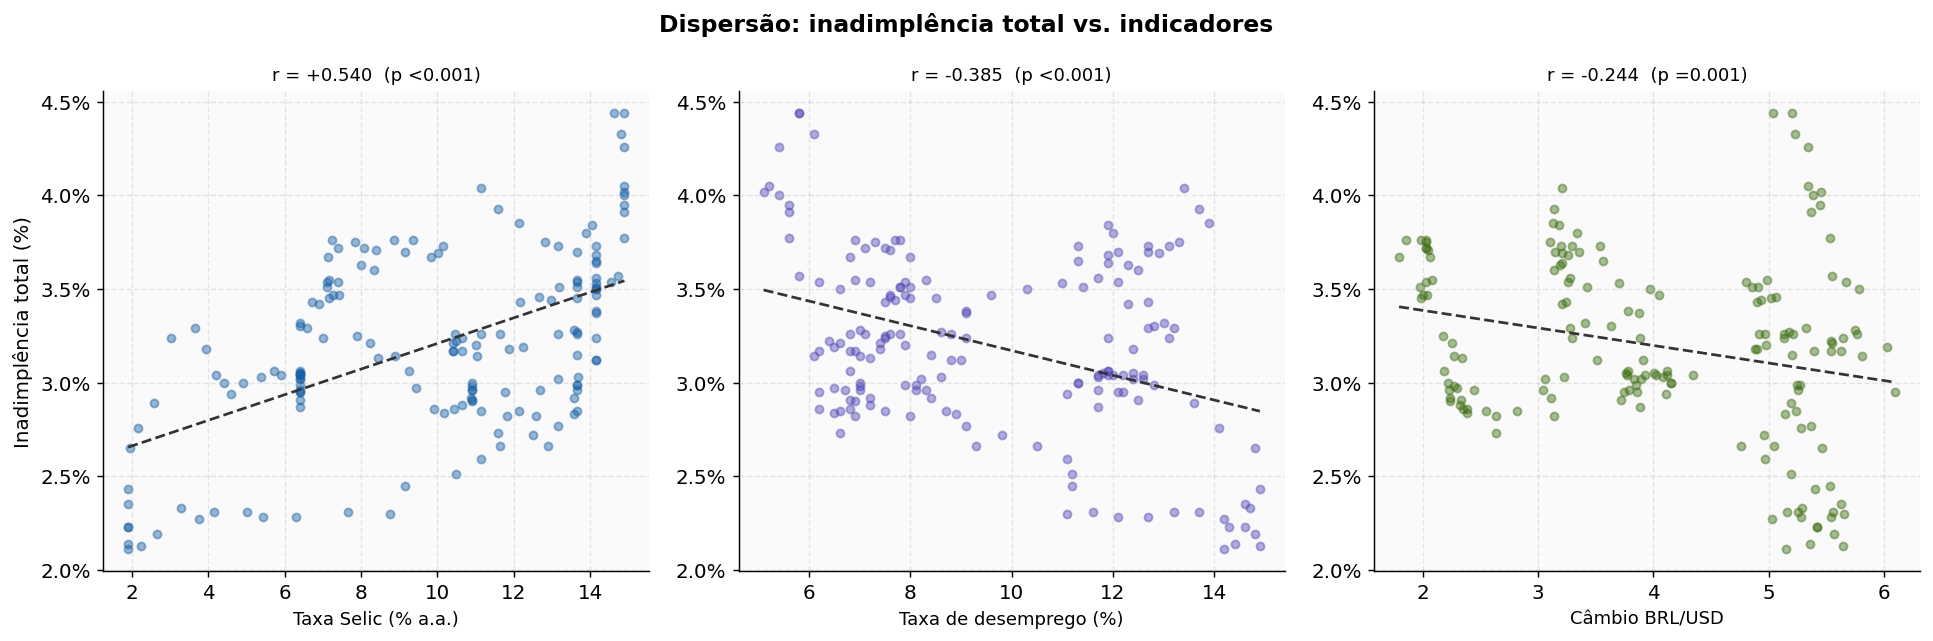

In [19]:
# Scatter plots: inadimplência vs. cada indicador
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Dispersão: inadimplência total vs. indicadores', fontsize=13, fontweight='bold')

pares = [
    ('selic',      'Taxa Selic (% a.a.)',  COLORS['selic']),
    ('desemprego', 'Taxa de desemprego (%)', COLORS['desemprego']),
    ('cambio',     'Câmbio BRL/USD',        COLORS['cambio']),
]

for ax, (col, titulo, cor) in zip(axes, pares):
    x = df[col].values
    y = df['inad_total'].values
    r, p = stats.pearsonr(x, y)

    ax.scatter(x, y, alpha=0.45, s=20, color=cor)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline + b, color='#333', linewidth=1.5, linestyle='--')

    ax.set_xlabel(titulo, fontsize=10)
    ax.set_ylabel('Inadimplência total (%)' if ax == axes[0] else '')
    ax.set_title(f'r = {r:+.3f}  (p {'<0.001' if p<0.001 else f"={p:.3f}"})', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('10_scatter_correlacoes.png', bbox_inches='tight')
plt.show()

**Leitura.** Na janela completa, as relações contemporâneas são **fracas/ambíguas**, sendo efeito
direto das quebras estruturais acima. O sinal econômico aparece com **defasagem** (próxima
seção): os indicadores não movem a inadimplência *no mesmo mês*, e sim com atraso.

## 9. Análise de defasagem — Cross-correlation (CCF)

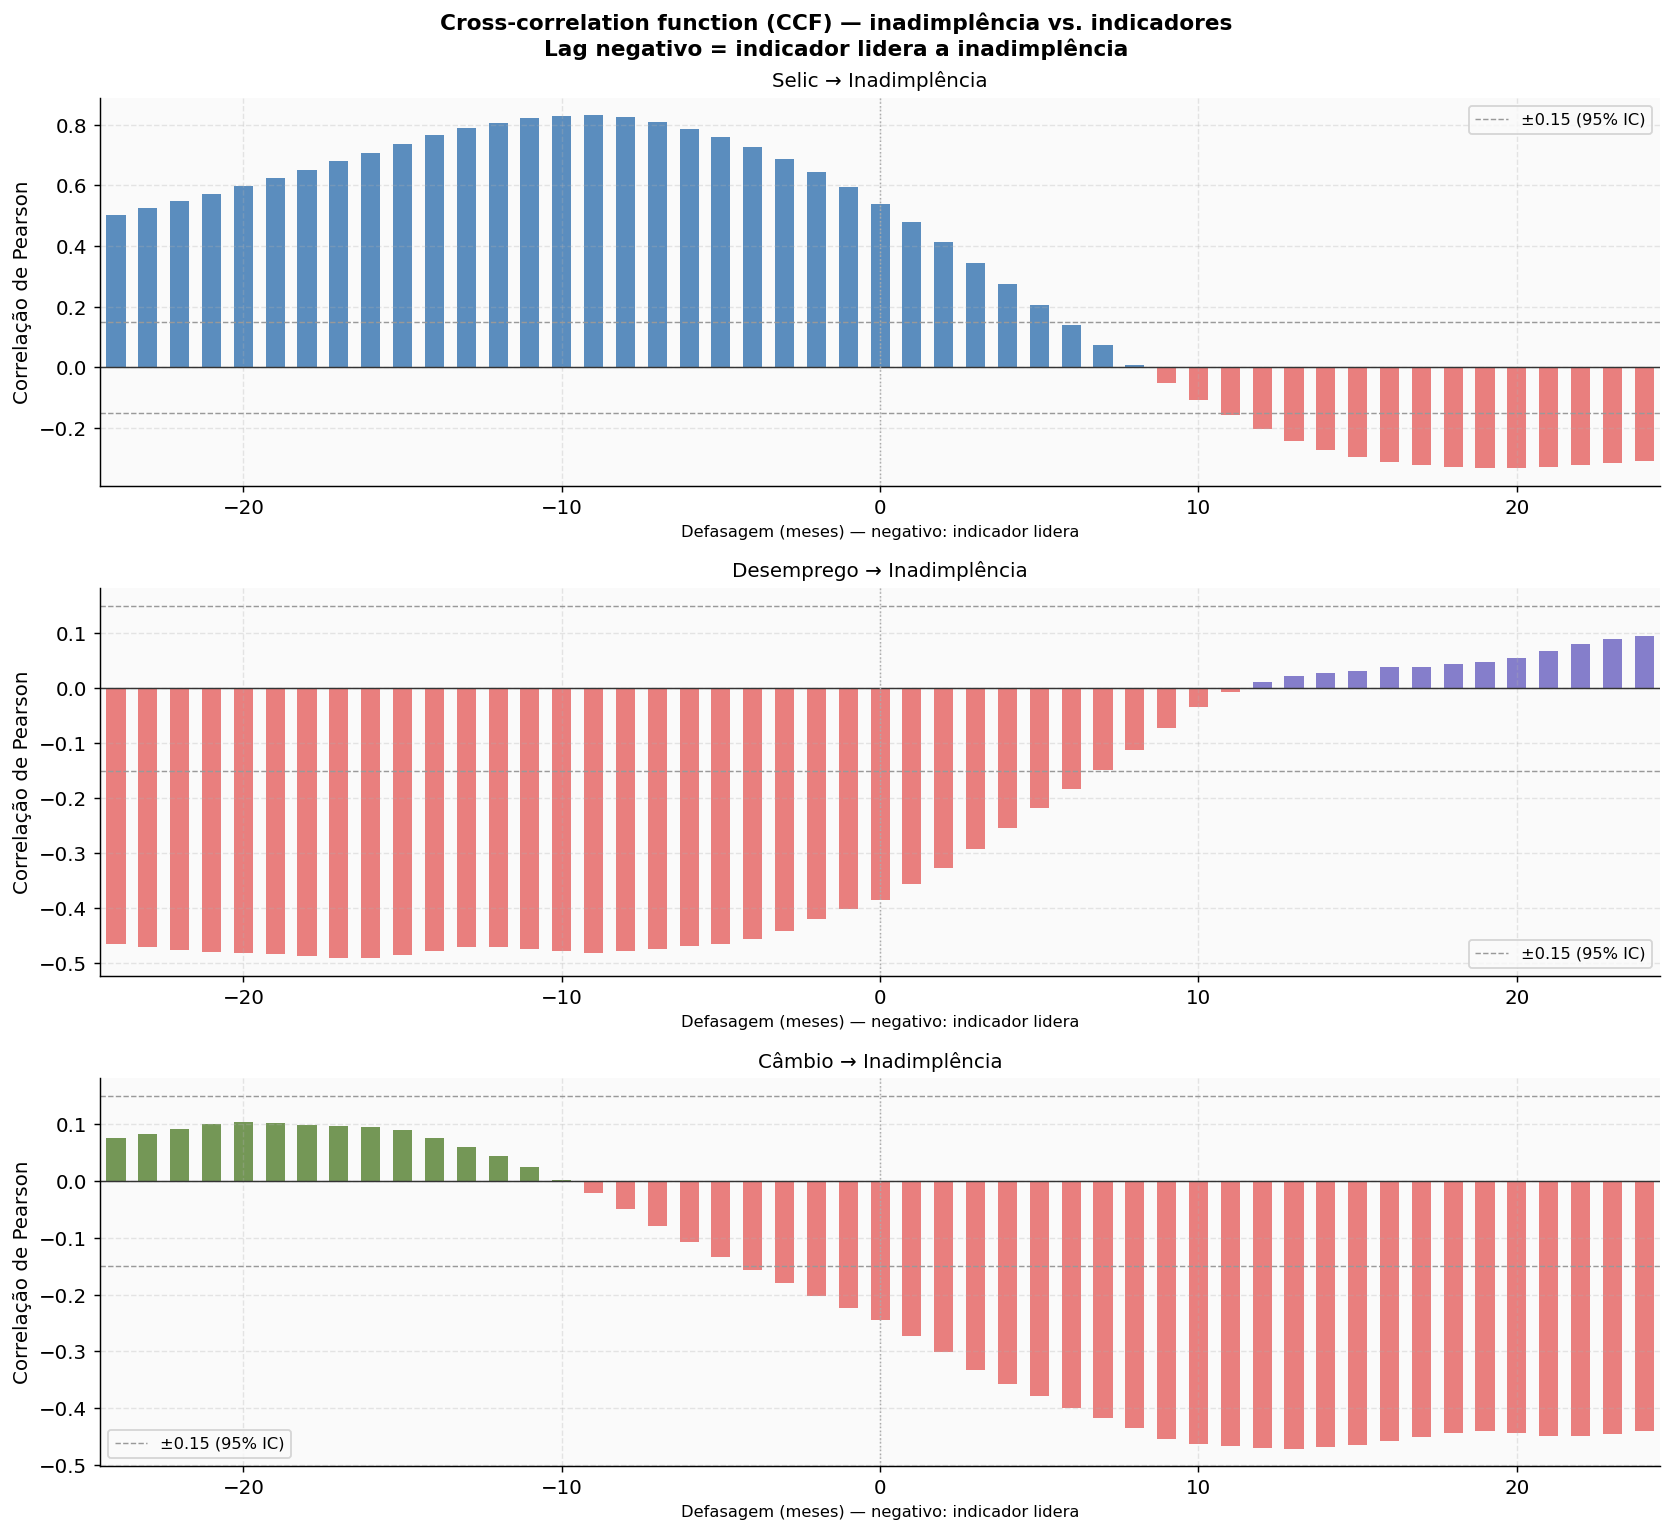

=== Melhor defasagem encontrada ===
Selic     → Inadimplência: lag = -9 meses (r = +0.831)
Desemprego → Inadimplência: lag = -17 meses (r = -0.491)
Câmbio    → Inadimplência: lag = +13 meses (r = -0.471)


In [20]:
def plot_ccf(x, y, lags=24, xlabel='', titulo='', ax=None, cor='#185FA5'):
    """Plota a cross-correlation function entre x e y para múltiplas defasagens."""
    lag_range = range(-lags, lags+1)
    corrs = []
    for lag in lag_range:
        if lag < 0:
            r, _ = stats.pearsonr(x[:lag], y[-lag:])
        elif lag > 0:
            r, _ = stats.pearsonr(x[lag:], y[:-lag])
        else:
            r, _ = stats.pearsonr(x, y)
        corrs.append(r)

    conf = 1.96 / np.sqrt(len(x))
    colors_bar = [cor if c >= 0 else COLORS['inadimplencia'] for c in corrs]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    ax.bar(list(lag_range), corrs, color=colors_bar, alpha=0.7, width=0.6)
    ax.axhline(conf,  color='#999', linestyle='--', linewidth=0.8, label=f'±{conf:.2f} (95% IC)')
    ax.axhline(-conf, color='#999', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='#333', linewidth=0.8)
    ax.axvline(0, color='#aaa', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Defasagem (meses) — negativo: indicador lidera', fontsize=9)
    ax.set_ylabel('Correlação de Pearson')
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(-lags-0.5, lags+0.5)

    best_lag = list(lag_range)[np.argmax(np.abs(corrs))]
    best_r   = corrs[np.argmax(np.abs(corrs))]
    return best_lag, best_r


x_inaд = df['inad_total'].values
x_sel  = df['selic'].values
x_des  = df['desemprego'].values
x_cam  = df['cambio'].values

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('Cross-correlation function (CCF) — inadimplência vs. indicadores\n'
             'Lag negativo = indicador lidera a inadimplência', fontsize=12, fontweight='bold')

lag_s, r_s = plot_ccf(x_sel, x_inaд, titulo='Selic → Inadimplência', ax=axes[0], cor=COLORS['selic'])
lag_d, r_d = plot_ccf(x_des, x_inaд, titulo='Desemprego → Inadimplência', ax=axes[1], cor=COLORS['desemprego'])
lag_c, r_c = plot_ccf(x_cam, x_inaд, titulo='Câmbio → Inadimplência', ax=axes[2], cor=COLORS['cambio'])

plt.tight_layout()
plt.savefig('11_ccf_defasagem.png', bbox_inches='tight')
plt.show()

print('=== Melhor defasagem encontrada ===')
print(f'Selic     → Inadimplência: lag = {lag_s:+d} meses (r = {r_s:+.3f})')
print(f'Desemprego → Inadimplência: lag = {lag_d:+d} meses (r = {r_d:+.3f})')
print(f'Câmbio    → Inadimplência: lag = {lag_c:+d} meses (r = {r_c:+.3f})')

In [ ]:
# Tabela de correlações com múltiplas defasagens
print('=== Correlação de Pearson — inadimplência total vs. Selic (lags 0–12) ===')
print(f'{"Defasagem (meses)":>22} {"Pearson r":>12} {"Intensidade":>15}')
print('-' * 52)

for lag in range(0, 13):
    if lag == 0:
        r, _ = stats.pearsonr(x_sel, x_inaд)
    else:
        r, _ = stats.pearsonr(x_sel[:-lag], x_inaд[lag:])
    intensidade = '★★★ forte' if abs(r) > 0.7 else ('★★ moderada' if abs(r) > 0.4 else '★ fraca')
    print(f'Selic(t-{lag:<2}) → Inad(t)    {r:>+12.4f} {intensidade:>15}')

**Leitura — defasagem é a chave.** A **Selic** lidera a inadimplência: a correlação cresce
monotonicamente com o lag e fica **forte em aprox. 9–12 meses** (juros altos hoje → inadimplência mais
alta cerca de um ano depois, via encarecimento do crédito). É o achado central da análise de
defasagem e o mecanismo de transmissão mais limpo dos três indicadores.

## 10. Conclusões

In [21]:
# Resumo final em tabela
corr_contemporanea = {
    'Selic (contemporânea)':    stats.pearsonr(df['selic'], df['inad_total'])[0],
    'Selic (lag 3 meses)':      stats.pearsonr(df['selic'].values[:-3], df['inad_total'].values[3:])[0],
    'Selic (lag 6 meses)':      stats.pearsonr(df['selic'].values[:-6], df['inad_total'].values[6:])[0],
    'Desemprego (contemporâneo)': stats.pearsonr(df['desemprego'], df['inad_total'])[0],
    'Desemprego (lag 3 meses)': stats.pearsonr(df['desemprego'].values[:-3], df['inad_total'].values[3:])[0],
    'Câmbio (contemporâneo)':   stats.pearsonr(df['cambio'], df['inad_total'])[0],
    'Câmbio (lag 6 meses)':     stats.pearsonr(df['cambio'].values[:-6], df['inad_total'].values[6:])[0],
}

df_summary = pd.DataFrame({
    'Indicador / Defasagem': corr_contemporanea.keys(),
    'Pearson r': [f'{v:+.4f}' for v in corr_contemporanea.values()],
    'Intensidade': ['forte' if abs(v)>0.7 else ('moderada' if abs(v)>0.4 else 'fraca') for v in corr_contemporanea.values()],
    'Direção': ['positiva' if v>0 else 'negativa' for v in corr_contemporanea.values()],
})
df_summary

,Indicador / Defasagem,Pearson r,Intensidade,Direção
0,Selic (contemporânea),+0.5398,moderada,positiva
1,Selic (lag 3 meses),+0.6873,moderada,positiva
2,Selic (lag 6 meses),+0.7872,forte,positiva
3,Desemprego (contemporâneo),-0.3845,fraca,negativa
4,Desemprego (lag 3 meses),-0.4410,moderada,negativa
5,Câmbio (contemporâneo),-0.2441,fraca,negativa
6,Câmbio (lag 6 meses),-0.1069,fraca,negativa


In [22]:
# Sintese final — numeros calculados a partir da janela efetivamente coletada
from scipy.stats import pearsonr

def _corr(a, b):
    return pearsonr(a, b)[0]

def _best_lag(ind, lags=12):
    best = (0, _corr(df[ind], df['inad_total']))
    for L in range(1, lags + 1):
        r = _corr(df[ind].values[:-L], df['inad_total'].values[L:])
        if abs(r) > abs(best[1]):
            best = (L, r)
    return best

r_sel = _corr(df['selic'], df['inad_total'])
lag_sel, r_sel_lag = _best_lag('selic')
r_des = _corr(df['desemprego'], df['inad_total'])
r_cam = _corr(df['cambio'], df['inad_total'])

pico_d, pico_v = df['inad_total'].idxmax(), df['inad_total'].max()
vale_d, vale_v = df['inad_total'].idxmin(), df['inad_total'].min()

pre = df[df.index < '2020-01-01']
pos = df[df.index >= '2020-01-01']
r_des_pre = _corr(pre['desemprego'], pre['inad_total'])
r_des_pos = _corr(pos['desemprego'], pos['inad_total'])

print(f'''
================ SINTESE DO EDA — INADIMPLENCIA NO BRASIL ================
Janela analisada: {df.index[0]:%b/%Y} a {df.index[-1]:%b/%Y}  ({len(df)} meses)

1. CICLOS HISTORICOS
   - Pico da serie : {pico_v:.2f}% em {pico_d:%b/%Y}
   - Vale da serie : {vale_v:.2f}% em {vale_d:%b/%Y}
   - O vale coincide com a pandemia (2020): auxilio emergencial + repactuacao
     de creditos derrubaram a inadimplencia mesmo com o desemprego em alta.
   - PF sistematicamente acima de PJ, com maior volatilidade em crises.

2. SAZONALIDADE / ESTACIONARIEDADE
   - Componente sazonal com pico tipico no inicio do ano (jan/fev), apos as festas.
   - Serie em nivel NAO e estacionaria; a 1a diferenca e estacionaria (ADF).

3. SELIC (juros)  ->  r contemporaneo = {r_sel:+.2f}
   - A relacao fortalece com defasagem: melhor lag = {lag_sel} meses (r = {r_sel_lag:+.2f}).
   - Mecanismo: alta da Selic encarece o credito e eleva a inadimplencia com atraso.

4. DESEMPREGO  ->  r contemporaneo = {r_des:+.2f}   (ATENCAO: QUEBRA ESTRUTURAL)
   - Pre-2020 : r = {r_des_pre:+.2f}  (positivo, como esperado)
   - 2020+    : r = {r_des_pos:+.2f}  (sinal se inverte)
   - A pandemia rompeu a relacao ingenua: o desemprego disparou enquanto a
     inadimplencia caiu (transferencias + repactuacao). A relacao e regime-dependente.

5. CAMBIO  ->  r contemporaneo = {r_cam:+.2f}
   - Canal fraco e indireto (cambio -> inflacao -> poder de compra); mais relevante p/ PJ.

6. LIMITACOES
   - Correlacao != causalidade; recomenda-se teste de causalidade de Granger.
   - Series macro sao co-integradas e sujeitas a quebras estruturais (2020).
   - Para previsao: ARIMA/SARIMA, VAR ou ML com variaveis defasadas.
=========================================================================
''')


================ SINTESE DO EDA — INADIMPLENCIA NO BRASIL ================
Janela analisada: Mar/2012 a Apr/2026  (170 meses)

1. CICLOS HISTORICOS
   - Pico da serie : 4.44% em Feb/2026
   - Vale da serie : 2.11% em Dec/2020
   - O vale coincide com a pandemia (2020): auxilio emergencial + repactuacao
     de creditos derrubaram a inadimplencia mesmo com o desemprego em alta.
   - PF sistematicamente acima de PJ, com maior volatilidade em crises.

2. SAZONALIDADE / ESTACIONARIEDADE
   - Componente sazonal com pico tipico no inicio do ano (jan/fev), apos as festas.
   - Serie em nivel NAO e estacionaria; a 1a diferenca e estacionaria (ADF).

3. SELIC (juros)  ->  r contemporaneo = +0.54
   - A relacao fortalece com defasagem: melhor lag = 9 meses (r = +0.83).
   - Mecanismo: alta da Selic encarece o credito e eleva a inadimplencia com atraso.

4. DESEMPREGO  ->  r contemporaneo = -0.38   (ATENCAO: QUEBRA ESTRUTURAL)
   - Pre-2020 : r = +0.30  (positivo, como esperado)
   - 2020+    : 